In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [3]:
data=pd.read_csv('sales_data.csv')
data['date']=pd.to_datetime(data['date'])
data['time_index']=np.arange(len(data))

In [5]:
X=data[['time_index']]
y=data['sales']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [7]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print('R2:',r2_score(y_test,y_pred))
print('MAE:',mean_absolute_error(y_test,y_pred))

R2: 0.8746913580246929
MAE: 7.333333333333276


In [9]:
future_index=np.arange(len(data),len(data)+6)
future_df=pd.DataFrame({'time_index':future_index})
pred=model.predict(future_df)

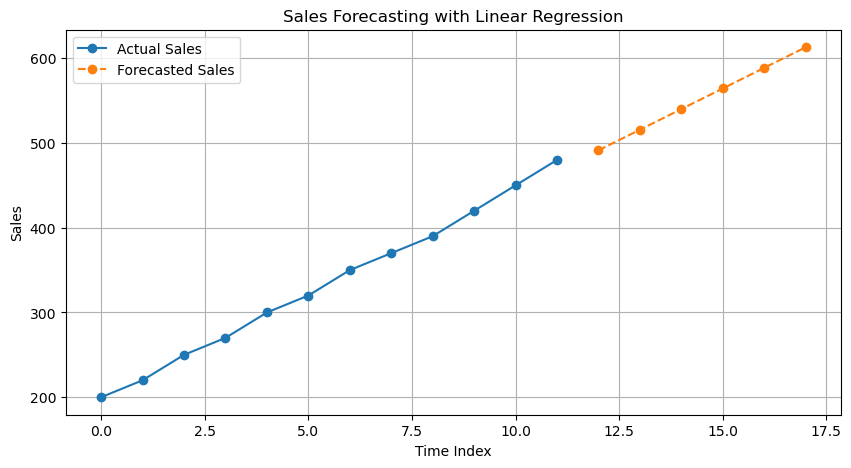

In [11]:
plt.figure(figsize=(10,5))
plt.plot(data['time_index'],y,marker='o',label='Actual Sales')
plt.plot(future_index,pred,'--o',label='Forecasted Sales')
plt.title('Sales Forecasting with Linear Regression')
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()